In [1]:
# general 
import scipy as sp
import pickle
from tqdm.notebook import tqdm
import json
import getdist
from getdist import plots, MCSamples
import matplotlib.pyplot as plt
import numpy as np

# density estimation 
from sbi.inference import NPE, NLE
import torch
from sbi.analysis import pairplot
from sbi.analysis import plot_summary
from sbi.utils import BoxUniform
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot

/opt/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
import subprocess

print("--- PyTorch & CUDA Status ---")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"PyTorch Compiled CUDA Version: {torch.version.cuda}")

print("\n--- System GPU Driver Status ---")
try:
    smi_output = subprocess.check_output(['nvidia-smi']).decode('utf-8')
    # Print the top lines showing Driver Version and CUDA Version
    for line in smi_output.split('\n')[:4]:
        print(line)
except Exception as e:
    print("Could not run nvidia-smi:", e)

--- PyTorch & CUDA Status ---
PyTorch Version: 2.13.0+cu126
CUDA Available: True
PyTorch Compiled CUDA Version: 12.6

--- System GPU Driver Status ---
Wed Sep 23 15:55:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+


In [3]:
# !/opt/venv/bin/python -m pip uninstall -y torch torchvision torchaudio
# !/opt/venv/bin/python -m pip cache purge
# !/opt/venv/bin/python -m pip install torch==2.13.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [4]:
# !df -h


In [3]:
import multiprocessing
num_cores = multiprocessing.cpu_count()
print(f'Number of CPU cores available: {num_cores}')

if torch.cuda.is_available():
    device = 'cuda'
    print(f'Device: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = 'mps'
    print(f'Device: MPS')    
else:
    device = 'cpu'
    print('Device: CPU')

Number of CPU cores available: 288
Device: NVIDIA GH200 120GB


The dimension of the s2MSE_L1500 parameter datset is (98304, 5)
The dimension of the s2MSE_L1500 compressed data dataset is (98304, 5)
The dimension of the s2VMIM_L1500 parameter datset is (98304, 5)
The dimension of the s2VMIM_L1500 compressed data dataset is (98304, 5)
(2, 98304, 5)
There are 98304 datapoints.


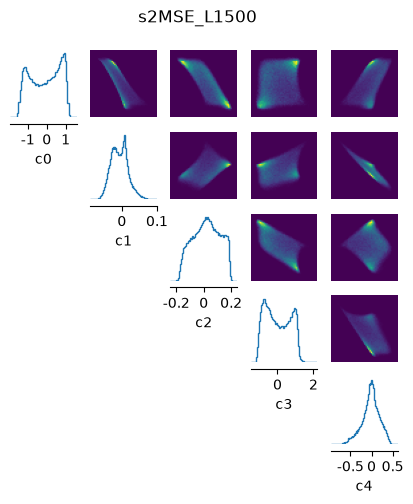

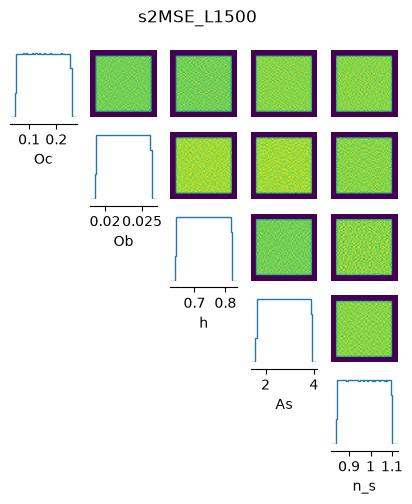

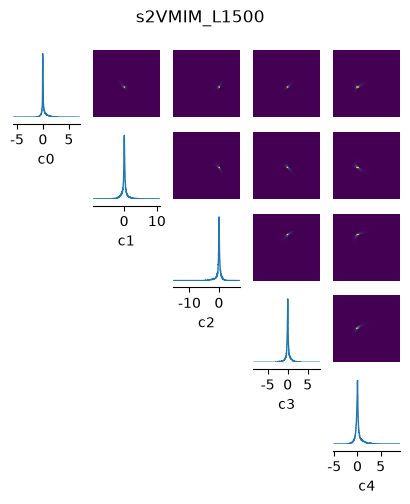

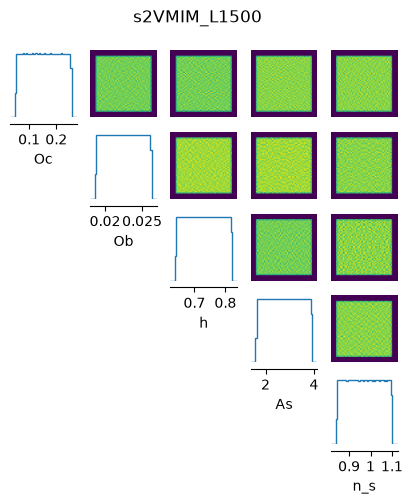

In [4]:
# compression_types = ["VMIM","MSE","CCA"]
# compression_types = ["s2MSE_L750", "s2VMIM_L750"]
compression_types = ["s2MSE_L1500", "s2VMIM_L1500"]
# compression_directories = [
#     "compressed_data/VMIM_4transforms_8bins_min-3.0_max3.0.pkl",
#     "compressed_data/MSE_sbi_lens.pkl",
#     "compressed_data/CCA_sbi_lens.pkl",
#     ]
# compression_directories = [
#     "/home/u6pf/brianycc.u6pf/sbi-compression/examples/compressed_data/s2MSE_L750_6000N_2200steps_64batch_0.002lr.pkl",
#     "/home/u6pf/brianycc.u6pf/sbi-compression/examples/compressed_data/s2VMIM_L750_6000N_1000steps_64batch_0.002lr.pkl"
# ]
compression_directories = [
    # "/home/u6pf/brianycc.u6pf/sbi-compression/examples/compressed_data/s2MSE_L1500_6000N_1200steps_32batch_0.002lr.pkl",
    '/projects/u6pf/brianycc/spherical_maps/map_compression_L1500_mwss_samples_augmented_pooled_compressed/s2MSE_L1500_98304N_6500steps_32batch_0.001lr.pkl',
    # "/home/u6pf/brianycc.u6pf/sbi-compression/examples/compressed_data/s2VMIM_L1500_6000N_1500steps_32batch_0.002lr.pkl",
    '/projects/u6pf/brianycc/spherical_maps/map_compression_L1500_mwss_samples_augmented_pooled_compressed/s2VMIM_L1500_98304N_6500steps_32batch_0.001lr_4transforms_8bins.pkl'
]
gt_list = []
cd_list = []
for i,c in enumerate(compression_types):
    with open(compression_directories[i], 'rb') as f:
        load = pickle.load(f)
        gt = load["ground_truth"]
        cd = load["compressed_data"]
        print(f'The dimension of the {c} parameter datset is', gt.shape)
        print(f'The dimension of the {c} compressed data dataset is', cd.shape)
        gt_list.append(gt)
        cd_list.append(cd)

param_names = ['Oc','Ob','h','As','n_s']
for i,(gt,cd) in enumerate(zip(gt_list,cd_list)):
    _ = pairplot(cd, figsize=(5,5), labels=['c0','c1','c2','c3','c4'])
    plt.suptitle(compression_types[i])
    _ = pairplot(gt, figsize=(5,5), labels=param_names)
    plt.suptitle(compression_types[i])

print(np.array(gt_list).shape)
N = np.array(gt_list).shape[1]
print(f'There are {N} datapoints.')
        

In [ ]:
i = 0
gt = gt_list[i]
cd = cd_list[i]

nle = NLE(density_estimator="nsf", device=device)

# Convert parameter and cls data to tensors for training
gt = torch.tensor(gt, dtype=torch.float32)
cd = torch.tensor(cd, dtype=torch.float32)
# Check whether the trainig data is of correct shape and network has been instantiated
print('parameter samples', type(gt), gt.shape, 'cls samples', type(cd), cd.shape)
print('Density estimation model:', nle)

nle = nle.append_simulations(gt, cd, data_device=device)
nle.train(
    training_batch_size=64,
    learning_rate=1e-3,
)

_ = plot_summary(nle)
with open(f"examples/trained_sbi_models/NLE_{compression_types[i]}_{N}N.pkl", "wb") as f:
    pickle.dump(nle, f)


parameter samples <class 'torch.Tensor'> torch.Size([98304, 5]) cls samples <class 'torch.Tensor'> torch.Size([98304, 5])
Density estimation model: <sbi.inference.trainers.nle.nle_a.NLE_A object at 0x40046a3263c0>


/opt/venv/lib/python3.13/site-packages/sbi/inference/trainers/base.py:303: UserWarning: Data x has device 'cpu'. Moving x to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(
/opt/venv/lib/python3.13/site-packages/sbi/inference/trainers/base.py:303: UserWarning: Parameters theta has device 'cpu'. Moving theta to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(


In [ ]:
from torch import Tensor
from torch.distributions import Normal, Distribution
from sbi.utils import MultipleIndependent, BoxUniform

with open(f"examples/trained_sbi_models/NLE_{compression_types[i]}.pkl", "rb") as f:
    nle = pickle.load(f)

# prior = MultipleIndependent([
#     BoxUniform(torch.tensor(0.05), torch.tensor(0.255)),
#     BoxUniform(torch.tensor(0.01875), torch.tensor(0.02625)),
#     BoxUniform(torch.tensor(0.64), torch.tensor(0.82)),
#     BoxUniform(torch.tensor(1.61), torch.tensor(3.91)),
#     BoxUniform(torch.tensor(0.84), torch.tensor(1.1)),
#     ],
#     device=device)

prior = BoxUniform(
    low=torch.tensor([0.05, 0.01875, 0.64, 1.61, 0.84], device=device),
    high=torch.tensor([0.255, 0.02625, 0.82, 3.91, 1.1], device=device)
)

posterior = nle.build_posterior(prior=prior)
print(posterior)
cd_obs = torch.tensor(cd[42,:]).detach()
gt_obs = torch.tensor(gt[42,:]).detach()
print('The compressed observation is', cd_obs)
print('The ground truth is', gt_obs)
n_samples = 1000
samples = posterior.sample((n_samples,), x=cd_obs).cpu().numpy()
posterior_data = {
    "samples": samples,
    "observation": cd_obs,
    "ground_truth": gt_obs,
}

with open(f"examples/posterior_samples/NLE_{compression_types[i]}_posterior_{n_samples}samples.pkl", "wb") as f:
    pickle.dump(posterior_data, f)
    print(f"posterior samples saved at: \nexamples/posterior_samples/NLE_{compression_types[i]}_posterior_{n_samples}samples.pkl")



/tmp/ipykernel_89543/841855089.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cd_obs = torch.tensor(cd[42,:]).detach()
/tmp/ipykernel_89543/841855089.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gt_obs = torch.tensor(gt[42,:]).detach()


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
The compressed observation is tensor([-0.2544,  0.2217,  0.1537, -0.1409, -0.0536])
The ground truth is tensor([0.1114, 0.0202, 0.7694, 3.7539, 0.9450])


Running vectorized MCMC with 20 chains: 100%|███████████████████████████████████████████████████████████| 6000/6000 [02:40<00:00, 37.34it/s]

posterior samples saved at: 
examples/posterior_samples/NLE_s2VMIM_L1500_posterior_1000samples.pkl


tensor([0.1114, 0.0202, 0.7694, 3.7539, 0.9450])


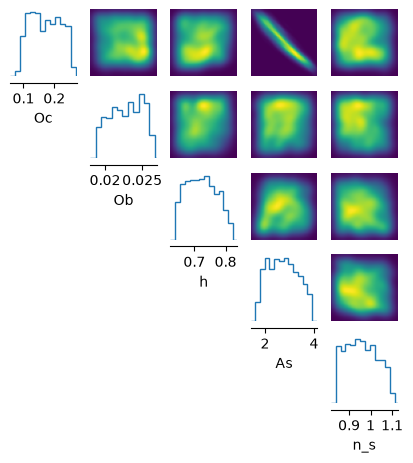

In [10]:
gt_obs = gt[42,:]
print(gt_obs)
_ = pairplot(samples, upper='kde', figsize=(5,5), labels=param_names)

Removed no burn in
Removed no burn in


/tmp/ipykernel_44021/3332608394.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


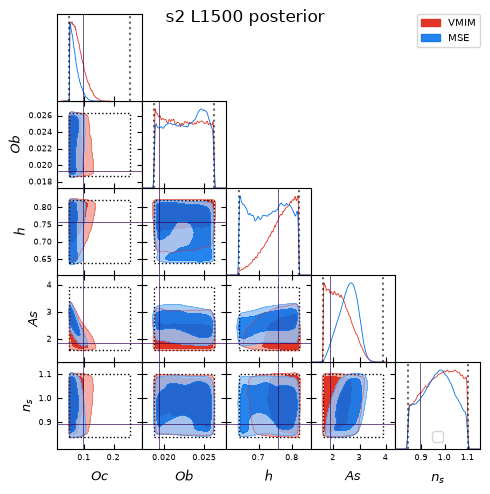

[0.09634019 0.01935966 0.7585867  1.8694075  0.89177376] [0.09634019 0.01935966 0.7585867  1.8694075  0.89177376]


In [7]:
n_samples = 98304
L = 1500
save_plot = True
data_type = 'augpool'

def to_cpu_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

with open(f"examples/posterior_samples/NLE_s2VMIM_L{L}_{data_type}_posterior_{n_samples}samples.pkl", "rb") as f:
    # vmim_samples = torch.load(f, map_location=torch.device('cpu'), weights_only=False)
    posterior_data = pickle.load(f)
    vmim_samples = to_cpu_numpy(posterior_data["samples"])
    vmim_obs = to_cpu_numpy(posterior_data["observation"])
    vmim_gt = to_cpu_numpy(posterior_data["ground_truth"])
with open(f"examples/posterior_samples/NLE_s2MSE_L{L}_{data_type}_posterior_{n_samples}samples.pkl", "rb") as f:
    # mse_samples = torch.load(f, map_location=torch.device('cpu'), weights_only=False)
    posterior_data = pickle.load(f)
    mse_samples = to_cpu_numpy(posterior_data["samples"])
    mse_obs = to_cpu_numpy(posterior_data["observation"])
    mse_gt = to_cpu_numpy(posterior_data["ground_truth"])

from matplotlib.patches import Rectangle
    
g = plots.get_subplot_plotter(subplot_size=1)

# set prior range for plotting
param_names = ['Oc','Ob','h','As','n_s']
prior_lower = [0.05, 0.01875, 0.64, 1.61, 0.84]
prior_upper = [0.255, 0.02625, 0.82, 3.91, 1.1]

# create a getdist MCSamples object with names/labels
vmim_mcs = MCSamples(
    samples=vmim_samples, 
    names=param_names, 
    labels=param_names,
    )
mse_mcs = MCSamples(
    samples=mse_samples, 
    names=param_names, 
    labels=param_names,
    )

# pass the MCSamples (not a nested list of lists)
g.triangle_plot(
    [vmim_mcs, mse_mcs], 
    # mse_mcs,
    filled=True, 
    legend_labels=["VMIM","MSE"],
    legend_loc="upper right",
    )

# Plot prior
n_params = len(param_names)
for i in range(n_params):
    for j in range(i + 1):

        ax = g.subplots[i, j]
        
        # X-axis corresponds to parameter j
        x_low, x_high = prior_lower[j], prior_upper[j]
        x_span = x_high - x_low
        ax.set_xlim([x_low - 0.2 * x_span, x_high + 0.2 * x_span])
        
        # Y-axis corresponds to parameter i (off-diagonal subplots only)
        if i != j:
            y_low, y_high = prior_lower[i], prior_upper[i]
            y_span = y_high - y_low
            ax.set_ylim([y_low - 0.2 * y_span, y_high + 0.2 * y_span])


        if i == j:
            # 1D diagonal subplot: vertical lines for the parameter's prior bounds
            ax.axvline(prior_lower[i], color='k', linestyle=':', alpha=0.6)
            ax.axvline(prior_upper[i], color='k', linestyle=':', alpha=0.6)
            ax.axvline(vmim_gt[i], color='darkred', linestyle='-', alpha=0.6, linewidth=0.5)
            ax.axvline(mse_gt[i], color='darkblue', linestyle='-', alpha=0.6, linewidth=0.5)
            
        else:
            # 2D off-diagonal subplot: empty rectangular box for the joint uniform prior
            # x-axis corresponds to parameter j, y-axis corresponds to parameter i
            x_low, x_high = prior_lower[j], prior_upper[j]
            y_low, y_high = prior_lower[i], prior_upper[i]

            ax.axvline(vmim_gt[j], color='darkred', linestyle='-', alpha=0.6, linewidth=0.5)
            ax.axhline(vmim_gt[i], color='darkred', linestyle='-', alpha=0.6, linewidth=0.5)
            ax.axvline(mse_gt[j], color='darkblue', linestyle='-', alpha=0.6, linewidth=0.5)
            ax.axhline(mse_gt[i], color='darkblue', linestyle='-', alpha=0.6, linewidth=0.5)
            
            rect = Rectangle(
                (x_low, y_low),
                x_high - x_low,
                y_high - y_low,
                fill=False,
                edgecolor='black',
                linestyle=':',
                linewidth=1,
                alpha=1
            )
            ax.add_patch(rect)

# g.add_param_markers(
#         {param_names[0]: cd_obs[0].item(), 
#         param_names[1]: cd_obs[1].item(), 
#         param_names[2]: cd_obs[2].item(), 
#         param_names[3]: cd_obs[3].item(), 
#         param_names[4]: cd_obs[4].item(), 
#         }
#     )

plt.legend()
plt.suptitle(F"s2 L{L} posterior")
if save_plot:
    plt.savefig(f"examples/plots/posteriors/s2VMIM_s2MSE_L{L}_{data_type}_posterior.pdf")
plt.show()

print(vmim_gt, mse_gt)